In [3]:
import pandas as pd 
from sklearn. tree import DecisionTreeClassifier 
from sklearn.model_selection import train_test_split 
from sklearn import metrics

In [5]:
df = pd. read_excel('lophoc.xlsx', sheet_name="data")
df

,Sức khỏe,Thời tiết,Kết quả
0,ốm,u ám,nghỉ
1,ốm,mưa,nghỉ
2,ốm,nắng,nghỉ
3,ốm,u ám,học
4,tốt,u ám,học
5,tốt,mưa,học
6,tốt,nắng,nghỉ


In [6]:
# Tập dữ liệu Input (đặc trưng) và Output (mục tiêu)
X = df. iloc[:,:-1] # Features
Y = df.iloc[:,-1]
# Target variable

In [7]:
X 
Y

0    nghỉ
1    nghỉ
2    nghỉ
3     học
4     học
5     học
6    nghỉ
Name: Kết quả, dtype: object

In [8]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder instances
encHealth = LabelEncoder()
encWeather = LabelEncoder()

# Apply LabelEncoder to the 'Sức khỏe' and 'Thời tiết' columns in the dataset X
X['Sức khỏe'] = encHealth.fit_transform(X['Sức khỏe'])
X['Thời tiết'] = encWeather.fit_transform(X['Thời tiết'])
X

C:\Users\Admin\AppData\Local\Temp\ipykernel_24104\3168575223.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Sức khỏe'] = encHealth.fit_transform(X['Sức khỏe'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_24104\3168575223.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Thời tiết'] = encWeather.fit_transform(X['Thời tiết'])


,Sức khỏe,Thời tiết
0,1,2
1,1,0
2,1,1
3,1,2
4,0,2
5,0,0
6,0,1


In [9]:
from sklearn.model_selection import train_test_split

# Split dataset into training set and test set (80% training, 20% testing)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=34)

In [10]:
X_train

,Sức khỏe,Thời tiết
4,0,2
6,0,1
5,0,0
2,1,1
1,1,0


In [11]:
# Create Decision Tree Classifier
modelDT = DecisionTreeClassifier(criterion="entropy", max_depth=3)

# Train Decision Tree Classifier
modelDT = modelDT.fit(X_train, Y_train)

In [12]:
modelDT.classes_

array(['học', 'nghỉ'], dtype=object)

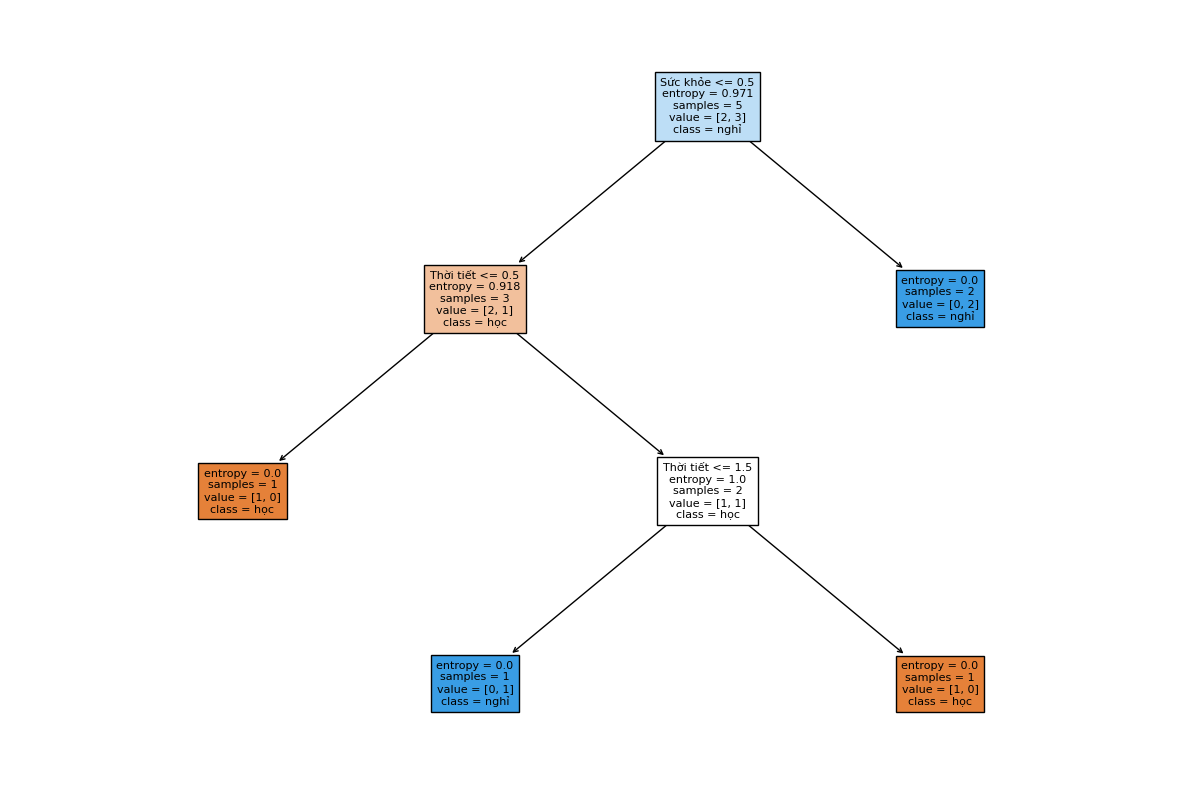

In [13]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Convert feature column names and class names to lists
feature_cols = list(X_train.columns)
class_names = list(modelDT.classes_)

# Plot the decision tree
plt.figure(figsize=(15, 10))
plot_tree(modelDT, feature_names=feature_cols, class_names=class_names, fontsize=8, filled=True)

# Display the plot
plt.show()

In [14]:
import numpy as np

# Example: Assume we have a sample with two classes
# For example, let's say we have 6 "yes" and 4 "no" in a binary classification sample

counts = np.array([6, 4])  # Frequencies of each class (6 "yes", 4 "no")
probabilities = counts / counts.sum()  # Probabilities of each class

# Calculate entropy
entropy = -np.sum(probabilities * np.log2(probabilities))

print(f"Entropy: {entropy}")

Entropy: 0.9709505944546686


In [16]:
import numpy as np

# Function to calculate entropy
def entropy(counts):
    probabilities = counts / counts.sum()
    return -np.sum([p * np.log2(p) for p in probabilities if p > 0])

# Dataset counts for target variable (e.g., "yes" and "no" in a binary classification)
counts = np.array([6, 4])  # 6 "yes" and 4 "no"
H_T = entropy(counts)  # Entropy of the entire dataset

# Now, let's assume we split on a feature with 2 values (e.g., "Feature A" has two values)
# Subsets after the split (Example: 4 "yes", 1 "no" in first subset, 2 "yes", 3 "no" in second subset)
subset1_counts = np.array([4, 1])  # First subset
subset2_counts = np.array([2, 3])  # Second subset

# Calculate the entropy for each subset
H_subset1 = entropy(subset1_counts)
H_subset2 = entropy(subset2_counts)

# Calculate weighted entropy
weighted_entropy = (5 / 10) * H_subset1 + (5 / 10) * H_subset2

# Calculate Information Gain
information_gain = H_T - weighted_entropy

print(f"Entropy of the entire dataset: {H_T}")
print(f"Weighted Entropy after the split: {weighted_entropy}")
print(f"Information Gain: {information_gain}")

Entropy of the entire dataset: 0.9709505944546686
Weighted Entropy after the split: 0.8464393446710154
Information Gain: 0.12451124978365313


In [17]:
# đánh giá nô hình
from sklearn import metrics

# Predict the response for the test dataset
y_test_pred = modelDT.predict(X_test)  # Corrected the model name to modelDT

# Model Accuracy: how often is the classifier correct?
print("Accuracy:", metrics.accuracy_score(Y_test, y_test_pred))

Accuracy: 0.5


In [18]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cf_matrix = confusion_matrix(Y_test, y_test_pred)

# Display the confusion matrix
print("Confusion Matrix:\n", cf_matrix)

Confusion Matrix:
 [[0 1]
 [0 1]]


In [19]:
# Assuming cf_matrix is the confusion matrix you obtained earlier
# cf_matrix = [[TN, FP],
#               [FN, TP]]

TN, FP, FN, TP = cf_matrix.ravel()  # Unpack the confusion matrix into TN, FP, FN, TP

# Calculate TPR, FNR, FPR, TNR
TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FNR = FN / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
TNR = TN / (FP + TN) if (FP + TN) > 0 else 0

# Print the metrics
print("True Positive Rate (TPR):", TPR)
print("False Negative Rate (FNR):", FNR)
print("False Positive Rate (FPR):", FPR)
print("True Negative Rate (TNR):", TNR)

True Positive Rate (TPR): 1.0
False Negative Rate (FNR): 0.0
False Positive Rate (FPR): 1.0
True Negative Rate (TNR): 0.0


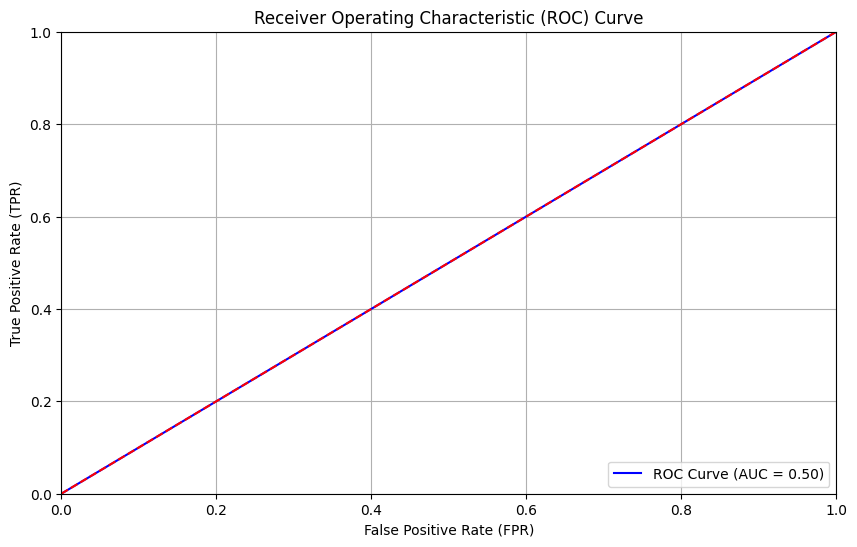

In [21]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Fit and transform the true labels
y_test_encoded = label_encoder.fit_transform(Y_test)  # Transforming y_test

# Now use y_test_encoded for ROC curve calculation
y_scores = modelDT.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_scores)  # Use encoded labels
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve (same as before)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [22]:
import numpy as np

# Sample input for prediction
health = 'ốm'
weather = 'nắng'

# Transforming the input features using the encoders
health_scaled = encHealth.transform([health])  # Transform health
weather_scaled = encWeather.transform([weather])  # Transform weather

# Create feature sample for prediction
feature_sample = np.array([[health_scaled[0], weather_scaled[0]]])

# Make prediction
sample_pred = modelDT.predict(feature_sample)

# Display the prediction
print("Predicted class:", sample_pred)

Predicted class: ['nghỉ']


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
